<a href="https://colab.research.google.com/github/rubusarbaro/supplychain-forecast-FIME/blob/main/Auto_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##############################################################################
###                            AutoML to Time Series                        ##
###                                S&OP                                     ##
###                      18/03/2025                                         ##
###                                                   xoce15@ingenieros.com ##
##############################################################################

# Instalacioón de librerias

In [ ]:
!pip install --q auto_ts
!pip install --q prophet

# Librerias

In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime
import math

from prophet import Prophet
#import auto_ts as AT
import pandas as pd
from google.colab import files

## Introducción

Se estará trabajando usando una libreria de [auto ML](/github.com/AutoViML/Auto_TS). La cual le permira facilmente entrenar varios modelos estadisticos y de Machine Learning para hacer una predicción

# Funciones

In [ ]:
def parse(x):
  return datetime.strptime(x,'%y/%m')

# Parametros

Vale la pena recordar que aqui se ponen las variables de interes para está practica. Tanto la columna donde están las fechas como la columna donde estan los valores.

In [ ]:
column_date= 'Fechas'
column_value='Cantidad'
sep = ','

porcentaje=0.93

# Lectura de datos

Se ha practicado con diferentes formas de cargar los datos a Google Colab.  Lo que vale la pena saber y/o entender es:

*   Donde están los datos
*   En que formato están los datos

El donde le permitira saber hay que tomarlos de un google drive, de un Github o si están en su maquina local y toca subirlos a la nube para poder tener acceso a ellos.

El identificar el formato le permitira evitar tener problemas con intentar leer un .xlxs con una función para leer .csv, recuerden en el aspecto de formato tambien está la estructura de las fechas. Vale la pena definir una y dejarsela claro al sistema.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Exploración visual

Muchas veces se hace una pequeña exploración visual de los datos para ver como vienen, que tipo de variables hay y si se ha leido correctamente la información cargada.

Libreria [AutoTs](https://pypi.org/project/AutoTS/)

In [ ]:
! pip install -qq AutoTS

In [ ]:
from autots.models.model_list import model_lists

print(model_lists.keys())

dict_keys(['all', 'default', 'fast', 'superfast', 'parallel', 'fast_parallel', 'fast_parallel_no_arima', 'scalable', 'probabilistic', 'multivariate', 'univariate', 'no_params', 'recombination_approved', 'no_shared', 'no_shared_fast', 'experimental', 'slow', 'gpu', 'regressor', 'best', 'motifs', 'all_result_path', 'regressions', 'all_pragmatic', 'update_fit'])



 ¿Cuantos modelos tiene está libreria para series de tiempo univariables?

In [ ]:
model_lists.values()

dict_values([['ConstantNaive', 'LastValueNaive', 'AverageValueNaive', 'GLS', 'GLM', 'ETS', 'ARIMA', 'FBProphet', 'RollingRegression', 'GluonTS', 'SeasonalNaive', 'UnobservedComponents', 'VECM', 'DynamicFactor', 'MotifSimulation', 'WindowRegression', 'VAR', 'DatepartRegression', 'UnivariateRegression', 'UnivariateMotif', 'MultivariateMotif', 'NVAR', 'MultivariateRegression', 'SectionalMotif', 'Theta', 'ARDL', 'NeuralProphet', 'DynamicFactorMQ', 'PytorchForecasting', 'ARCH', 'RRVAR', 'MAR', 'TMF', 'LATC', 'KalmanStateSpace', 'MetricMotif', 'Cassandra', 'SeasonalityMotif', 'MLEnsemble', 'PreprocessingRegression', 'FFT', 'BallTreeMultivariateMotif', 'TiDE', 'NeuralForecast'], {'ConstantNaive': 1, 'LastValueNaive': 1, 'AverageValueNaive': 1, 'GLS': 1, 'SeasonalNaive': 1, 'GLM': 1, 'ETS': 1, 'FBProphet': 0.5, 'UnobservedComponents': 1, 'VAR': 1, 'VECM': 1, 'ARIMA': 0.4, 'WindowRegression': 0.5, 'DatepartRegression': 1, 'UnivariateRegression': 0.3, 'MultivariateRegression': 0.4, 'UnivariateMo

In [ ]:
#quieron=['univariate','multivariate']

#print(model_lists[quieron])

Algunos parametros de está libreria

**Forecast_length =** ¿Cuánto en el futuro desea pronosticar? Cuanto mayor sea la duración, los resultados pueden ser erróneos para las marcas de tiempo posteriores

**Frecuencia =** La frecuencia de los datos de entrenamiento (día, mes, año, segundo, etc.)

**Intervalo de predicción =** Similar al concepto de intervalos de confianza que usamos en las estadísticas. 0,95 representa un intervalo de confianza del 95 %.

**ensemble =** Ensembling se refiere a la fusión de dos o modelos, entrenados sobre algunos datos comunes, para llegar al resultado final. El ensamblaje se puede hacer de múltiples maneras. Los diferentes valores que puede tomar este hiperparámetro son Ninguno, predeterminado, simple, etc.

**model_list=** El hiperparámetro más importante, model_list, nos brinda una amplia gama de opciones para seleccionar un conjunto de modelos para entrenar y encontrar la mejor opción entre todas las demás para que el entrenamiento sea más rápido.

In [ ]:
from autots import AutoTS
df=pd.read_csv(path+'/'+'Air_dos.csv',encoding='unicode_escape', date_parser=parse)

df.columns=['Fechas','Cantidad']

df['Fechas']=pd.to_datetime(df['Fechas'], errors='coerce')

#df= df.groupby(['Fechas']).agg({'Cantidad':'sum'}).reset_index()


ec_df = df.set_index(column_date)

ec_df= ec_df.asfreq('D')
ec_df= ec_df.sort_index()

<ipython-input-34-b48879dfb6d9>:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df=pd.read_csv(path+'/'+'Air_dos.csv',encoding='unicode_escape', date_parser=parse)


,Cantidad
Fechas,
2022-06-20,214013.0
2022-06-21,218393.0
2022-06-22,240666.0
2022-06-23,243108.0
2022-06-24,212638.0
...,...
2024-02-28,419338.0
2024-02-29,422112.0
2024-03-01,393184.0


In [ ]:
model_list = [
    'FBProphet',
    'GLS',
    'ETS',
    'ARIMA',
    'NeuralProphet',
]


model2 = AutoTS(
    forecast_length=15,
    frequency='D',
    prediction_interval=0.95,
    ensemble=None,
    models_mode='deep',
    model_list = model_list,
    max_generations=5,
    num_validations=2,
    no_negatives=True,
    n_jobs='auto')


model2.fit(ec_df[column_value])
prediction = model2.predict(forecast_length=30)

Using 1 cpus for n_jobs.
Data frequency is: D, used frequency is: D
Model Number: 1 with model ARIMA in generation 0 of 5
Model Number: 2 with model ETS in generation 0 of 5
Model Number: 3 with model ETS in generation 0 of 5
Model Number: 4 with model GLS in generation 0 of 5
Model Number: 5 with model GLS in generation 0 of 5
Model Number: 6 with model FBProphet in generation 0 of 5


DEBUG:cmdstanpy:input tempfile: /tmp/tmpsnh0lwl4/qtpj4nvg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsnh0lwl4/0cri04jx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=45482', 'data', 'file=/tmp/tmpsnh0lwl4/qtpj4nvg.json', 'init=/tmp/tmpsnh0lwl4/0cri04jx.json', 'output', 'file=/tmp/tmpsnh0lwl4/prophet_modelyn997bsu/prophet_model-20240410013820.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:38:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:38:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Model Number: 7 with model ETS in generation 0 of 5
Model Number: 8 with model FBProphet in generation 0 of 5
Model Number: 9 with model FBProphet in generation 0 of 5
Model Number: 10 with model GLS in generation 0 of 5
Model Number: 11 with model ETS in generation 0 of 5
Model Number: 12 with model ARIMA in generation 0 of 5
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 12 in generation 0: ARIMA
Model Number: 13 with model NeuralProphet in generation 0 of 5
Template Eval Error: ModuleNotFoundError("No module named 'neuralprophet'") in model 13 in generation 0: NeuralProphet
Model Number: 14 with model ARIMA in generation 0 of 5
Model Number: 15 with model NeuralProphet in generation 0 of 5
Template Eval Error: ModuleNotFoundError("No module named 'neuralprophet'") in model 15 in generation 0: NeuralProphet
Model Number: 16 with model GLS in generation 0 of 5
Model Number: 17 with model ETS in generation 0 of 5
Model Number: 18 wi

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Model Number: 44 with model GLS in generation 1 of 5
Model Number: 45 with model ARIMA in generation 1 of 5
Model Number: 46 with model ETS in generation 1 of 5
Model Number: 47 with model ETS in generation 1 of 5
Model Number: 48 with model FBProphet in generation 1 of 5
Template Eval Error: ValueError("regression_type='User' but no future_regressor passed") in model 48 in generation 1: FBProphet
Model Number: 49 with model ETS in generation 1 of 5
Model Number: 50 with model ARIMA in generation 1 of 5
Model Number: 51 with model ETS in generation 1 of 5
Model Number: 52 with model FBProphet in generation 1 of 5
Template Eval Error: ValueError("regression_type='User' but no future_regressor passed") in model 52 in generation 1: FBProphet
Model Number: 53 with model FBProphet in generation 1 of 5
Model Number: 54 with model ETS in generation 1 of 5
Model Number: 55 with model FBProphet in generation 1 of 5
Model Number: 56 with model FBProphet in generation 1 of 5
Model Number: 57 with

...

4 - ARIMA with avg smape 9.76: 
Model Number: 5 of 23 with model FBProphet for Validation 2
5 - FBProphet with avg smape 17.42: 
Model Number: 6 of 23 with model ETS for Validation 2
6 - ETS with avg smape 16.02: 
Model Number: 7 of 23 with model FBProphet for Validation 2
7 - FBProphet with avg smape 16.57: 
Model Number: 8 of 23 with model ETS for Validation 2
8 - ETS with avg smape 16.0: 
Model Number: 9 of 23 with model FBProphet for Validation 2
9 - FBProphet with avg smape 16.57: 
Model Number: 10 of 23 with model ETS for Validation 2
📈 10 - ETS with avg smape 6.1: 
Model Number: 11 of 23 with model ETS for Validation 2
11 - ETS with avg smape 15.97: 
Model Number: 12 of 23 with model ETS for Validation 2


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


12 - ETS with avg smape 15.97: 
Model Number: 13 of 23 with model ETS for Validation 2
13 - ETS with avg smape 15.97: 
Model Number: 14 of 23 with model FBProphet for Validation 2


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


14 - FBProphet with avg smape 17.1: 
Model Number: 15 of 23 with model ARIMA for Validation 2
📈 15 - ARIMA with avg smape 3.76: 
Model Number: 16 of 23 with model ARIMA for Validation 2
16 - ARIMA with avg smape 8.19: 
Model Number: 17 of 23 with model ARIMA for Validation 2
17 - ARIMA with avg smape 44.86: 
Model Number: 18 of 23 with model ARIMA for Validation 2
18 - ARIMA with avg smape 31.03: 
Model Number: 19 of 23 with model GLS for Validation 2
19 - GLS with avg smape 7.83: 
Model Number: 20 of 23 with model GLS for Validation 2
20 - GLS with avg smape 12.56: 
Model Number: 21 of 23 with model GLS for Validation 2
21 - GLS with avg smape 14.6: 
Model Number: 22 of 23 with model GLS for Validation 2
22 - GLS with avg smape 14.6: 
Model Number: 23 of 23 with model GLS for Validation 2
23 - GLS with avg smape 16.59: 


In [ ]:
example_filename = "Trabajo.final.csv"
model2.export_template(example_filename, models='best',
					  n=15, max_per_model_class=3)


In [ ]:
model2.best_model_name, print("\t"), model2.best_model_params,  print("\t"), model2.best_model_transformation_params

('ARIMA',
 None,
 {'p': 12, 'd': 1, 'q': 1, 'regression_type': 'Holiday'},
 None,
 {'fillna': 'quadratic',
  'transformations': {'0': 'Slice',
   '1': 'SeasonalDifference',
   '2': 'HolidayTransformer',
   '3': 'KalmanSmoothing',
   '4': 'AlignLastValue'},
  'transformation_params': {'0': {'method': 0.9},
   '1': {'lag_1': 168, 'method': 'Mean'},
   '2': {'threshold': 0.9,
    'splash_threshold': None,
    'use_dayofmonth_holidays': True,
    'use_wkdom_holidays': True,
    'use_wkdeom_holidays': False,
    'use_lunar_holidays': True,
    'use_lunar_weekday': False,
    'use_islamic_holidays': False,
    'use_hebrew_holidays': True,
    'anomaly_detector_params': {'method': 'IQR',
     'method_params': {'iqr_threshold': 2.5, 'iqr_quantiles': [0.25, 0.75]},
     'fillna': 'fake_date',
     'transform_dict': {'transformations': {'0': 'DifferencedTransformer'},
      'transformation_params': {'0': {}}},
     'isolated_only': False},
    'remove_excess_anomalies': False,
    'impact': 'ano

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

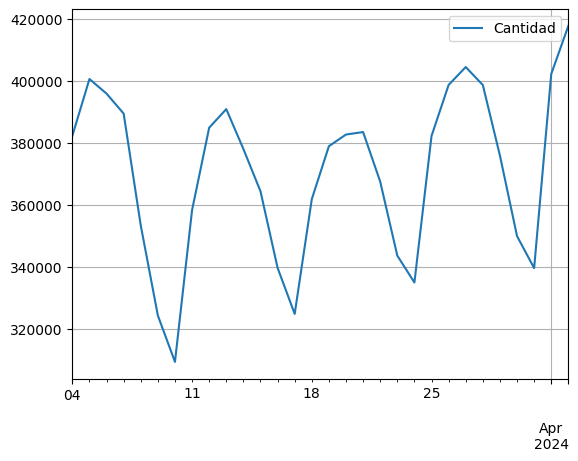

In [ ]:
forecasts_df = prediction.forecast

forecasts_df.plot(grid=True)

forecasts_df.to_csv('salida.csv',index=False,encoding='utf-8')
files.download('salida.csv')

El resultado del codigo siguiente estará aqui

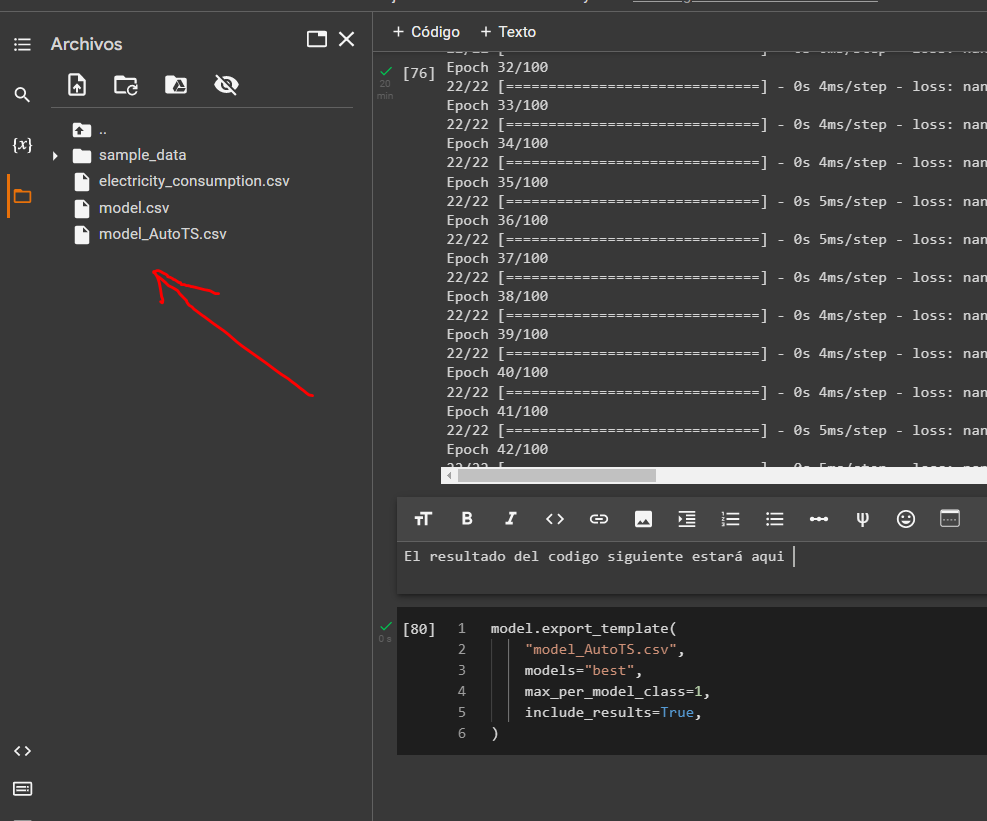

# Descarga de files

In [ ]:
forecasts_df.to_csv("model_AutoTS.csv", index=False)
files.download( "model_AutoTS.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>